> Part of **Complete Machine Learning Study Material** — split across per-chapter notebooks. See [`00_index.ipynb`](00_index.ipynb) for the notebook conventions, the per-concept template, the chapter coverage tracker and the cross-reference index.

## 15. Naive Bayes

*Scope:* A probabilistic classifier built directly on Bayes' theorem, and the deliberately wrong assumption that makes it fast.

Naive Bayes is the only model in this material built directly from probability theory rather than from an
optimization problem. There is no loss function, no gradient and no iteration — fitting is counting.

It is also the only model here whose central assumption is known in advance to be false. Understanding why
it works anyway is the interesting part.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, ComplementNB
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.width", 115)
sns.set_theme(style="whitegrid")

cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
print("ready")

ready


### 15.1 Bayes' Theorem as a Classifier

2.7.3 introduced Bayes' theorem. Applied to classification, the quantity we want is the probability of each
class given the observed features:

$$P(y = c \mid \mathbf{x}) = \frac{P(\mathbf{x} \mid y = c)\,P(y = c)}{P(\mathbf{x})}$$

| Term | Name | Estimated by |
|---|---|---|
| $P(y = c)$ | **Prior** | The class frequency in the training data |
| $P(\mathbf{x} \mid y = c)$ | **Likelihood** | A distribution fitted per class (15.4) |
| $P(\mathbf{x})$ | **Evidence** | Never computed — see below |
| $P(y = c \mid \mathbf{x})$ | **Posterior** | The prediction |

To *classify*, the evidence can be dropped entirely: $P(\mathbf{x})$ is the same for every class, so it
cannot change which class is largest.

$$\hat{y} = \arg\max_c \; P(\mathbf{x} \mid y = c)\,P(y = c)$$

It is needed only if you want the posteriors to sum to 1, in which case it is recovered by normalizing.

In [2]:
# A worked example by hand: 2 classes, one binary feature.
# Class priors and the likelihood of observing feature=1 in each class.
prior = {"spam": 0.30, "ham": 0.70}
likelihood = {"spam": 0.80, "ham": 0.10}          # P(contains "free" | class)

unnormalized = {c: likelihood[c] * prior[c] for c in prior}
evidence = sum(unnormalized.values())
posterior = {c: v / evidence for c, v in unnormalized.items()}

print("unnormalized scores (likelihood x prior):")
for c, v in unnormalized.items():
    print(f"  {c:<5} {v:.4f}")
print(f"\nevidence P(x) = {evidence:.4f}")
print("posteriors:")
for c, v in posterior.items():
    print(f"  {c:<5} {v:.4f}")
print(f"\nargmax is the same either way: "
      f"{max(unnormalized, key=unnormalized.get)} == {max(posterior, key=posterior.get)}")

unnormalized scores (likelihood x prior):
  spam  0.2400
  ham   0.0700

evidence P(x) = 0.3100
posteriors:
  spam  0.7742
  ham   0.2258

argmax is the same either way: spam == spam


Note how strongly the prior matters. The word appears in 80% of spam and only 10% of ham — an 8:1
likelihood ratio — but because ham is more than twice as common, the posterior is 77%, not 89%. That is
2.7.3's base-rate lesson operating inside the classifier.

### 15.2 The Naive Independence Assumption

The likelihood $P(\mathbf{x} \mid y = c)$ is a **joint** distribution over all $p$ features. Estimating it
properly is hopeless: with 20 binary features there are $2^{20}$ combinations, and no dataset contains
enough examples of each.

Naive Bayes makes the assumption that gives it its name — **features are conditionally independent given
the class**:

$$P(\mathbf{x} \mid y = c) = \prod_{j=1}^{p} P(x_j \mid y = c)$$

A joint distribution over $p$ features collapses into $p$ separate one-dimensional distributions.

In [3]:
for p in (5, 10, 20, 50):
    joint = 2 ** p
    naive = 2 * p
    print(f"{p:>3} binary features -> joint needs {joint:>12,} parameters, "
          f"naive needs {naive:>4}   ({joint / naive:>12,.0f}x fewer)")

  5 binary features -> joint needs           32 parameters, naive needs   10   (           3x fewer)
 10 binary features -> joint needs        1,024 parameters, naive needs   20   (          51x fewer)
 20 binary features -> joint needs    1,048,576 parameters, naive needs   40   (      26,214x fewer)
 50 binary features -> joint needs 1,125,899,906,842,624 parameters, naive needs  100   (11,258,999,068,426x fewer)


**The assumption is essentially always false.** In text, "New" and "York" co-occur constantly; in customer
data, tenure and total charges are near-deterministic functions of each other. Naive Bayes assumes
otherwise anyway.

#### 15.2.1 Why it works despite being wrong

The key insight is that classification needs only the **argmax** to be right, not the probabilities. The
independence assumption systematically distorts the magnitudes while often preserving the ordering.

Correlated features get their evidence **double-counted**, which pushes posteriors towards 0 and 1 — the
over-confidence that made Naive Bayes the worst-calibrated model in 8.7's comparison. But if both copies of
the evidence point the same way, the winner does not change.

In [4]:
# Two identical features: the second carries no new information, but NB counts it twice.
n = 600
signal = rng.normal(size=n)
y_dup = (signal > 0).astype(int)

X_one = signal.reshape(-1, 1)
X_dup = np.column_stack([signal, signal + rng.normal(0, 0.01, n)])   # a near-duplicate

for label, Xv in (("one copy of the feature", X_one), ("two near-identical copies", X_dup)):
    m = GaussianNB().fit(Xv, y_dup)
    proba = m.predict_proba(Xv)[:, 1]
    print(f"{label:<28} accuracy {m.score(Xv, y_dup):.4f}   "
          f"mean confidence {np.maximum(proba, 1 - proba).mean():.4f}")

one copy of the feature      accuracy 0.9967   mean confidence 0.8813


two near-identical copies    accuracy 0.9967   mean confidence 0.9423


Duplicating the feature leaves accuracy unchanged and pushes the average confidence higher: the same
evidence was counted twice. **The decision survives; the probability does not.** That is the precise sense
in which Naive Bayes "works despite being wrong", and 15.8 returns to what it costs.

### 15.3 Gaussian Naive Bayes from Scratch

For continuous features, the standard choice models each feature within each class as a normal
distribution (2.7.2):

$$P(x_j \mid y = c) = \frac{1}{\sqrt{2\pi\sigma_{cj}^2}} \exp\!\left(-\frac{(x_j - \mu_{cj})^2}{2\sigma_{cj}^2}\right)$$

**Fitting is counting and averaging.** For each class $c$ and feature $j$, estimate $\mu_{cj}$ and
$\sigma_{cj}^2$ from the rows of that class — nothing is optimized.

In [5]:
class GaussianNBScratch:
    """Gaussian Naive Bayes. Fitting is just per-class means and variances."""

    def fit(self, X, y, var_smoothing=1e-9):
        self.classes_ = np.unique(y)
        self.priors_ = np.array([(y == c).mean() for c in self.classes_])
        self.theta_ = np.array([X[y == c].mean(axis=0) for c in self.classes_])
        # sklearn adds var_smoothing * max(variance over all features) to every variance
        epsilon = var_smoothing * X.var(axis=0).max()
        self.var_ = np.array([X[y == c].var(axis=0) for c in self.classes_]) + epsilon
        return self

    def _joint_log_likelihood(self, X):
        """log P(x | c) + log P(c), one column per class.  Work in log space (15.6)."""
        jll = []
        for i in range(len(self.classes_)):
            log_prior = np.log(self.priors_[i])
            log_likelihood = -0.5 * (
                np.log(2 * np.pi * self.var_[i])
                + (X - self.theta_[i]) ** 2 / self.var_[i]
            ).sum(axis=1)
            jll.append(log_prior + log_likelihood)
        return np.array(jll).T

    def predict(self, X):
        return self.classes_[self._joint_log_likelihood(X).argmax(axis=1)]

    def predict_proba(self, X):
        jll = self._joint_log_likelihood(X)
        # normalize in log space: subtract the log of the summed exponentials
        log_evidence = np.log(np.exp(jll - jll.max(axis=1, keepdims=True)).sum(axis=1,
                                                                               keepdims=True))
        log_evidence += jll.max(axis=1, keepdims=True)
        return np.exp(jll - log_evidence)


print("fitted parameters per class: a prior, p means, p variances - no iteration")

fitted parameters per class: a prior, p means, p variances - no iteration


In [6]:
from sklearn.datasets import load_wine

wine = load_wine()
Xw, yw = wine.data, wine.target
Xw_tr, Xw_te, yw_tr, yw_te = train_test_split(Xw, yw, test_size=0.3, stratify=yw,
                                              random_state=RANDOM_STATE)

mine = GaussianNBScratch().fit(Xw_tr, yw_tr)
theirs = GaussianNB().fit(Xw_tr, yw_tr)

print("class priors:")
print(f"  from scratch : {mine.priors_.round(6)}")
print(f"  scikit-learn : {theirs.class_prior_.round(6)}")
print("\nper-class means, first 3 features:")
print(f"  from scratch :\n{mine.theta_[:, :3].round(4)}")
print(f"  scikit-learn :\n{theirs.theta_[:, :3].round(4)}")

class priors:
  from scratch : [0.3306 0.4032 0.2661]
  scikit-learn : [0.3306 0.4032 0.2661]

per-class means, first 3 features:
  from scratch :
[[13.7305  1.9471  2.4498]
 [12.2424  1.9626  2.2328]
 [13.0745  3.2009  2.4542]]
  scikit-learn :
[[13.7305  1.9471  2.4498]
 [12.2424  1.9626  2.2328]
 [13.0745  3.2009  2.4542]]


**Step 4 of the contract.**

In [7]:
print("means     match:", np.allclose(mine.theta_, theirs.theta_))
print("variances match:", np.allclose(mine.var_, theirs.var_))
print("priors    match:", np.allclose(mine.priors_, theirs.class_prior_))

p_mine = mine.predict(Xw_te)
p_theirs = theirs.predict(Xw_te)
print(f"\npredictions identical: {np.array_equal(p_mine, p_theirs)}")
print(f"max probability difference: "
      f"{np.abs(mine.predict_proba(Xw_te) - theirs.predict_proba(Xw_te)).max():.2e}")
print(f"\ntest accuracy: {accuracy_score(yw_te, p_mine):.4f}")

means     match: True
variances match: True
priors    match: True

predictions identical: True
max probability difference: 3.33e-15

test accuracy: 1.0000


#### 15.3.1 What the fitted model looks like

Because each feature is modelled independently within each class, the whole model is a grid of
one-dimensional bell curves. That is worth seeing, because it shows immediately what the model can and
cannot represent.

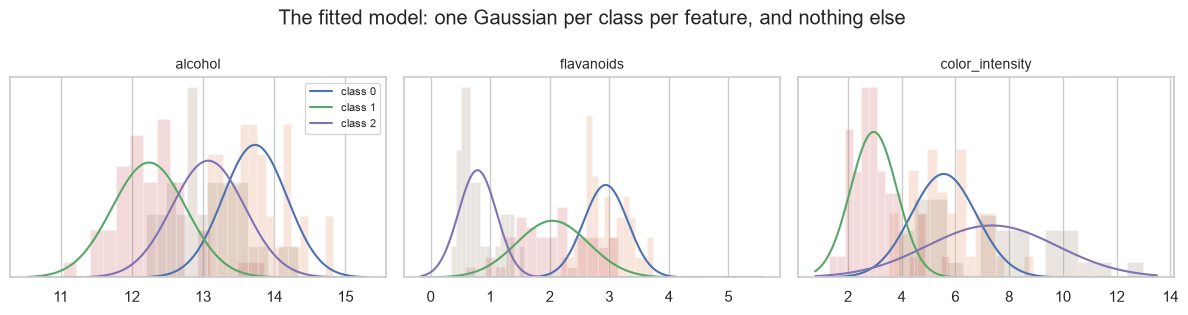

In [8]:
from scipy.stats import norm

feature_idx = [0, 6, 9]          # alcohol, flavanoids, colour intensity
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))

for ax, j in zip(axes, feature_idx):
    lo, hi = Xw[:, j].min(), Xw[:, j].max()
    grid = np.linspace(lo - 0.5, hi + 0.5, 300)
    for c in range(3):
        ax.plot(grid, norm.pdf(grid, mine.theta_[c, j], np.sqrt(mine.var_[c, j])),
                label=f"class {c}")
        ax.hist(Xw_tr[yw_tr == c, j], bins=15, density=True, alpha=0.2)
    ax.set_title(wine.feature_names[j], fontsize=10)
    ax.set_yticks([])
axes[0].legend(fontsize=8)
fig.suptitle("The fitted model: one Gaussian per class per feature, and nothing else")
fig.tight_layout()
plt.show()

Each panel is a separate, independent claim about one feature. The model never represents *"class 0 has
high alcohol **and** high flavanoids"* — only the two marginal statements. That is the independence
assumption drawn.

### 15.4 The Naive Bayes Family

The variants differ only in which distribution models $P(x_j \mid y = c)$.

| Variant | Models each feature as | Input must be | Typical use |
|---|---|---|---|
| `GaussianNB` | A normal distribution | Continuous, any sign | General tabular data |
| `MultinomialNB` | Counts from a multinomial | **Non-negative** counts or TF-IDF | Text (15.7) |
| `BernoulliNB` | A binary presence/absence indicator | Binary (or binarized) | Short text, presence features |
| `ComplementNB` | Multinomial, fitted on the *complement* of each class | Non-negative | **Imbalanced** text |
| `CategoricalNB` | A categorical distribution per feature | Integer-encoded categories | Purely categorical data |

In [9]:
from sklearn.feature_extraction.text import CountVectorizer

docs = [
    "the service was slow and support was unhelpful",
    "price increased again and service stayed slow",
    "excellent support fast and reliable service",
    "the price is fair and support is excellent",
    "slow slow slow and unhelpful support",
    "fast reliable and excellent value",
]
sentiment = np.array([0, 0, 1, 1, 0, 1])

counts = CountVectorizer().fit_transform(docs).toarray()
binary = (counts > 0).astype(int)

print(f"count matrix shape: {counts.shape}")
for name, model, data in (("MultinomialNB", MultinomialNB(), counts),
                          ("BernoulliNB", BernoulliNB(), binary),
                          ("ComplementNB", ComplementNB(), counts)):
    m = model.fit(data, sentiment)
    print(f"{name:<16} training accuracy {m.score(data, sentiment):.3f}")

count matrix shape: (6, 17)
MultinomialNB    training accuracy 1.000
BernoulliNB      training accuracy 1.000
ComplementNB     training accuracy 1.000


**`MultinomialNB` refuses negative input**, which is the most common error when someone standardizes their
features first out of habit (5.5). Naive Bayes needs no scaling — each feature is modelled on its own
scale — and scaling actively breaks the count-based variants.

In [10]:
from sklearn.preprocessing import StandardScaler

scaled_counts = StandardScaler().fit_transform(counts)
try:
    MultinomialNB().fit(scaled_counts, sentiment)
except ValueError as e:
    print("MultinomialNB on standardized data ->", str(e)[:70])

print("\nGaussianNB is scale-invariant - the fitted means and variances just rescale:")
raw_acc = cross_val_score(GaussianNB(), Xw, yw, cv=cv).mean()
scaled_acc = cross_val_score(GaussianNB(), StandardScaler().fit_transform(Xw), yw, cv=cv).mean()
print(f"  unscaled CV accuracy {raw_acc:.6f}")
print(f"  scaled   CV accuracy {scaled_acc:.6f}")

MultinomialNB on standardized data -> Negative values in data passed to MultinomialNB (input X).

GaussianNB is scale-invariant - the fitted means and variances just rescale:
  unscaled CV accuracy 0.971905
  scaled   CV accuracy 0.977460


### 15.5 Smoothing and the Zero-Frequency Problem

The likelihood is a **product** (15.2). If any single factor is zero, the entire product is zero —
regardless of how much evidence the other features provide.

This happens constantly in text: a word that never appeared in the spam training set gets
$P(\text{word} \mid \text{spam}) = 0$, so any message containing it has probability zero of being spam,
whatever else it says.

In [11]:
vocab = ["free", "money", "meeting", "report"]
# Counts of each word in each class. "report" never appears in spam.
word_counts = {"spam": np.array([30, 25, 2, 0]),
               "ham": np.array([3, 5, 40, 35])}

print("unsmoothed P(word | class):")
for c, counts_c in word_counts.items():
    probs = counts_c / counts_c.sum()
    print(f"  {c:<5} {dict(zip(vocab, probs.round(4)))}")

message = ["free", "money", "report"]
for c, counts_c in word_counts.items():
    probs = counts_c / counts_c.sum()
    joint = np.prod([probs[vocab.index(w)] for w in message])
    print(f"\nP({message} | {c}) = {joint:.6g}")

unsmoothed P(word | class):
  spam  {'free': np.float64(0.5263), 'money': np.float64(0.4386), 'meeting': np.float64(0.0351), 'report': np.float64(0.0)}
  ham   {'free': np.float64(0.0361), 'money': np.float64(0.0602), 'meeting': np.float64(0.4819), 'report': np.float64(0.4217)}

P(['free', 'money', 'report'] | spam) = 0

P(['free', 'money', 'report'] | ham) = 0.000918174


The message contains two strong spam indicators and one word never seen in spam, and the spam likelihood is
**exactly zero**. The classifier cannot call it spam under any circumstances.

**Laplace (additive) smoothing** fixes this by adding a pseudo-count $\alpha$ to every count:

$$P(x_j \mid y = c) = \frac{\text{count}(x_j, c) + \alpha}{\text{count}(c) + \alpha \cdot |V|}$$

$\alpha = 1$ is Laplace smoothing; $\alpha < 1$ is Lidstone. scikit-learn's default is `alpha=1.0`.

In [12]:
def smoothed(counts_c, alpha, vocab_size):
    return (counts_c + alpha) / (counts_c.sum() + alpha * vocab_size)


print(f"{'alpha':>8}   P(report | spam)   P(message | spam)")
for alpha in (0.0, 0.01, 0.1, 1.0):
    probs = smoothed(word_counts["spam"], alpha, len(vocab))
    joint = np.prod([probs[vocab.index(w)] for w in message])
    print(f"{alpha:>8}{probs[3]:>19.6f}{joint:>20.6g}")

   alpha   P(report | spam)   P(message | spam)
     0.0           0.000000                   0
    0.01           0.000175         4.04428e-05
     0.1           0.001742         0.000399489
     1.0           0.016393          0.00355096


Any $\alpha > 0$ removes the hard zero. The choice of $\alpha$ is a bias–variance decision (9.2): larger
values pull every estimate towards uniform, which protects against rare-word noise and dilutes genuine
evidence.

In [13]:
print(f"{'alpha':>8}{'CV accuracy':>14}")
for alpha in (0.001, 0.01, 0.1, 1.0, 10.0, 100.0):
    score = cross_val_score(MultinomialNB(alpha=alpha), counts, sentiment,
                            cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE)).mean()
    print(f"{alpha:>8}{score:>14.4f}")

   alpha   CV accuracy
   0.001        0.8333
    0.01        0.8333


     0.1        1.0000


     1.0        1.0000
    10.0        1.0000
   100.0        1.0000


**`GaussianNB` has an analogous problem and an analogous fix.** If a feature has zero variance within a
class — every training row of that class shares the same value — the Gaussian density is a spike and
dividing by $\sigma^2 = 0$ produces infinities. `var_smoothing` adds a small constant to every variance,
which is the line in 15.3's `fit` that looked like an implementation detail.

In [14]:
X_const = np.array([[1.0, 5.0], [1.0, 6.0], [1.0, 7.0],      # feature 0 is constant in class 0
                    [2.0, 5.0], [3.0, 6.0], [4.0, 7.0]])
y_const = np.array([0, 0, 0, 1, 1, 1])

no_smoothing = GaussianNB(var_smoothing=0.0)
try:
    no_smoothing.fit(X_const, y_const)
    print("variance of feature 0 in class 0:", no_smoothing.var_[0, 0])
    print("predict_proba:", no_smoothing.predict_proba([[1.0, 5.5]]))
except Exception as e:
    print("without smoothing ->", type(e).__name__, str(e)[:60])

with_smoothing = GaussianNB().fit(X_const, y_const)     # default var_smoothing=1e-9
print(f"\nwith default var_smoothing, variance = {with_smoothing.var_[0, 0]:.3e}")
print("predict_proba:", with_smoothing.predict_proba([[1.0, 5.5]]).round(6))

variance of feature 0 in class 0:

 0.0
predict_proba: [[nan nan]]

with default var_smoothing, variance = 1.333e-09
predict_proba: [[1. 0.]]


D:\Study Materials\ML\.venv\Lib\site-packages\sklearn\naive_bayes.py:538: RuntimeWarning: divide by zero encountered in log
  n_ij = -0.5 * xp.sum(xp.log(2.0 * xp.pi * self.var_[i, :]))
D:\Study Materials\ML\.venv\Lib\site-packages\sklearn\naive_bayes.py:540: RuntimeWarning: invalid value encountered in divide
  ((X - self.theta_[i, :]) ** 2) / (self.var_[i, :]), axis=1
D:\Study Materials\ML\.venv\Lib\site-packages\sklearn\utils\_array_api.py:1362: RuntimeWarning: divide by zero encountered in log
  out = xp.log1p(s) + xp.log(m) + array_max


### 15.6 Working in Log Space

2.9.3 showed a product of 800 small probabilities underflowing to exactly `0.0`. Naive Bayes multiplies one
probability per feature, so on any text problem the product underflows almost immediately.

The fix is to take logarithms, turning the product into a sum:

$$\log P(\mathbf{x} \mid c) + \log P(c) = \log P(c) + \sum_{j=1}^{p} \log P(x_j \mid c)$$

The argmax is unchanged, because $\log$ is strictly increasing.

In [15]:
probabilities = rng.uniform(0.001, 0.1, 500)       # 500 features, each a small likelihood

naive_product = np.prod(probabilities)
log_sum = np.log(probabilities).sum()

print(f"product in normal space : {naive_product}")
print(f"sum of logs             : {log_sum:.2f}")
print(f"\nhow many factors before underflow?")
running = 1.0
for i, p in enumerate(probabilities, 1):
    running *= p
    if running == 0.0:
        print(f"  underflowed to exactly 0.0 after {i} factors")
        break

product in normal space : 0.0
sum of logs             : -1605.21

how many factors before underflow?
  underflowed to exactly 0.0 after 229 factors


Comparing two classes in normal space would be comparing `0.0` against `0.0` — a coin flip. In log space
both are ordinary negative numbers and the comparison is exact.

In [16]:
# The same comparison, both ways.
spam_factors = rng.uniform(0.001, 0.1, 400)
ham_factors = rng.uniform(0.0005, 0.08, 400)

print("normal space:")
print(f"  spam {np.prod(spam_factors):.6g}   ham {np.prod(ham_factors):.6g}"
      f"   -> indistinguishable")
print("log space:")
ls, lh = np.log(spam_factors).sum(), np.log(ham_factors).sum()
print(f"  spam {ls:.2f}   ham {lh:.2f}   -> {'spam' if ls > lh else 'ham'} wins, decisively")

normal space:
  spam 0   ham 0   -> indistinguishable
log space:
  spam -1314.62   ham -1394.84   -> spam wins, decisively


scikit-learn exposes both, and `predict_log_proba` is the one to use whenever the numbers themselves
matter.

In [17]:
nb = GaussianNB().fit(Xw_tr, yw_tr)
row = Xw_te[:1]

print("predict_proba    :", nb.predict_proba(row).round(8))
print("predict_log_proba:", nb.predict_log_proba(row).round(4))
print("\nconsistent:", np.allclose(np.exp(nb.predict_log_proba(row)), nb.predict_proba(row)))
print(f"\nnote the smallest probability: {nb.predict_proba(row).min():.3e}")
print("in log space that is an ordinary number; in normal space it is near the edge of float precision.")

predict_proba    : [[1. 0. 0.]]
predict_log_proba: [[ -0.     -19.0547 -67.7347]]

consistent: True

note the smallest probability: 3.830e-30
in log space that is an ordinary number; in normal space it is near the edge of float precision.


**The log-sum-exp trick** is how the normalization in 15.3's `predict_proba` avoided overflow: subtract the
maximum before exponentiating, exactly as 13.7's softmax did.

In [18]:
log_scores = np.array([-800.0, -805.0, -810.0])     # realistic log-likelihoods

print("naive exp:", np.exp(log_scores), "  <- all zero, ratios lost")
shifted = log_scores - log_scores.max()
print("after subtracting the max:", np.exp(shifted).round(6))
print("normalized posteriors    :", (np.exp(shifted) / np.exp(shifted).sum()).round(6))

naive exp: [0. 0. 0.]   <- all zero, ratios lost
after subtracting the max: [1.     0.0067 0.    ]
normalized posteriors    : [0.9933 0.0067 0.    ]


### 15.7 Text Classification End to End

Text is where Naive Bayes earned its reputation: the feature count is enormous, the independence assumption
is badly violated, and it works well anyway.

In [19]:
# A labelled corpus built locally rather than downloaded (0.7), and deliberately hard:
# one sentiment word per review, heavy cross-contamination, and 5% mislabelled rows.
positive_words = ["excellent", "great", "fast", "reliable", "helpful", "value",
                  "smooth", "recommend", "clear", "responsive"]
negative_words = ["slow", "unhelpful", "expensive", "broken", "confusing", "rude",
                  "delayed", "poor", "useless", "frustrating"]
neutral_words = ["service", "support", "price", "account", "team", "product",
                 "update", "call", "email", "plan", "month", "time"]

CONTAMINATION = 0.45      # how often a review also contains the OTHER sentiment
LABEL_NOISE = 0.05        # how often the recorded label is simply wrong


def make_review(is_positive, gen):
    own = positive_words if is_positive else negative_words
    other = negative_words if is_positive else positive_words
    words = list(gen.choice(own, size=1))
    words += list(gen.choice(neutral_words, size=gen.integers(5, 11)))
    if gen.random() < CONTAMINATION:
        words += list(gen.choice(other, size=gen.integers(1, 3)))
    gen.shuffle(words)
    return " ".join(words)


gen = np.random.default_rng(RANDOM_STATE)
true_labels = gen.integers(0, 2, 1400)
corpus = [make_review(bool(lbl), gen) for lbl in true_labels]

labels = true_labels.copy()
flip = gen.random(len(labels)) < LABEL_NOISE
labels[flip] = 1 - labels[flip]

print(f"{len(corpus)} reviews, {labels.mean():.1%} positive, {flip.mean():.1%} mislabelled")
print("\nexamples:")
for i in (0, 1, 2):
    print(f"  [{'pos' if labels[i] else 'neg'}] {corpus[i]}")

1400 reviews, 52.1% positive, 5.3% mislabelled

examples:
  [neg] account account value support team month price useless
  [pos] product plan email responsive month account account email plan
  [pos] support service time update service responsive email product service price account


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline

txt_tr, txt_te, ytxt_tr, ytxt_te = train_test_split(corpus, labels, test_size=0.3,
                                                    stratify=labels, random_state=RANDOM_STATE)

pipelines = {
    "CountVectorizer + MultinomialNB": make_pipeline(CountVectorizer(), MultinomialNB()),
    "TfidfVectorizer + MultinomialNB": make_pipeline(TfidfVectorizer(), MultinomialNB()),
    "CountVectorizer + BernoulliNB": make_pipeline(CountVectorizer(binary=True), BernoulliNB()),
    "TF-IDF + bigrams + MultinomialNB": make_pipeline(
        TfidfVectorizer(ngram_range=(1, 2)), MultinomialNB()),
}

for name, pipe in pipelines.items():
    pipe.fit(txt_tr, ytxt_tr)
    proba = pipe.predict_proba(txt_te)[:, 1]
    print(f"{name:<36} accuracy {pipe.score(txt_te, ytxt_te):.4f}   "
          f"AUC {roc_auc_score(ytxt_te, proba):.4f}")

CountVectorizer + MultinomialNB      accuracy 0.6095   AUC 0.6505
TfidfVectorizer + MultinomialNB      accuracy 0.6119   AUC 0.6991


CountVectorizer + BernoulliNB        accuracy 0.6452   AUC 0.6721
TF-IDF + bigrams + MultinomialNB     accuracy 0.6143   AUC 0.6647


The model is readable, which is unusual for a text classifier. `feature_log_prob_` holds
$\log P(\text{word} \mid c)$, so the difference between the two rows ranks words by how much they favour
one class.

In [21]:
best = make_pipeline(CountVectorizer(), MultinomialNB()).fit(txt_tr, ytxt_tr)
vec, model = best[0], best[1]

words = np.array(vec.get_feature_names_out())
log_ratio = model.feature_log_prob_[1] - model.feature_log_prob_[0]    # positive minus negative

order = np.argsort(log_ratio)
print("most NEGATIVE-leaning words:")
for j in order[:6]:
    print(f"  {words[j]:<14} log-ratio {log_ratio[j]:>7.3f}")
print("\nmost POSITIVE-leaning words:")
for j in order[-6:][::-1]:
    print(f"  {words[j]:<14} log-ratio {log_ratio[j]:>7.3f}")

most NEGATIVE-leaning words:
  delayed        log-ratio  -0.632
  frustrating    log-ratio  -0.595
  unhelpful      log-ratio  -0.521
  poor           log-ratio  -0.519
  slow           log-ratio  -0.430
  expensive      log-ratio  -0.425

most POSITIVE-leaning words:
  value          log-ratio   0.559
  reliable       log-ratio   0.499
  helpful        log-ratio   0.365
  clear          log-ratio   0.362
  smooth         log-ratio   0.291
  excellent      log-ratio   0.283


Every one of those twelve words comes from the correct generating pool, on a corpus where the classifier
only reaches about 61% accuracy. **The model recovered the vocabulary without being told it**, and the
log-ratios are small (±0.6 rather than ±3) precisely because the contamination makes each word weak
evidence.

That readability is a real advantage: a misclassified document can be diagnosed by listing which words
drove the decision, with no separate explainability machinery (Chapter 24).

**`ComplementNB` for imbalanced text.** `MultinomialNB` is biased towards the majority class when the
classes are skewed, because the majority class's word counts dominate. `ComplementNB` estimates each
class's parameters from the *complement* of that class, which corrects the bias.

In [22]:
# Make the corpus heavily imbalanced: 10% positive.
keep = np.r_[np.flatnonzero(labels == 0), np.flatnonzero(labels == 1)[:60]]
corpus_imb = [corpus[i] for i in keep]
y_imb = labels[keep]

ci_tr, ci_te, yi_tr, yi_te = train_test_split(corpus_imb, y_imb, test_size=0.3,
                                              stratify=y_imb, random_state=RANDOM_STATE)
print(f"imbalanced corpus: {y_imb.mean():.1%} positive")

from sklearn.metrics import f1_score, average_precision_score

for name, nb_model in (("MultinomialNB", MultinomialNB()), ("ComplementNB", ComplementNB())):
    pipe = make_pipeline(CountVectorizer(), nb_model).fit(ci_tr, yi_tr)
    pred = pipe.predict(ci_te)
    proba = pipe.predict_proba(ci_te)[:, 1]
    print(f"{name:<16} accuracy {pipe.score(ci_te, yi_te):.4f}   "
          f"F1 {f1_score(yi_te, pred, zero_division=0):.4f}   "
          f"AP {average_precision_score(yi_te, proba):.4f}   "
          f"positives predicted {int(pred.sum()):>3}")

imbalanced corpus: 8.2% positive
MultinomialNB    accuracy 0.9132   F1 0.0000   AP 0.0748   positives predicted   1
ComplementNB     accuracy 0.6530   F1 0.0952   AP 0.0748   positives predicted  66


`MultinomialNB` scores the **higher accuracy and an F1 of exactly 0.000** — it predicts the majority class
for every single document, which is 8.5.1's failure mode arriving in a real model. `ComplementNB` gives up
26 points of accuracy to actually predict some positives.

Neither is good here: the corpus is deliberately hard and 8% positive, so this is a genuinely difficult
problem rather than a showcase. But the comparison makes the point that matters — **`MultinomialNB`'s
answer was a model that had learned to ignore the minority class entirely, and accuracy would have
reported that as the better result.**

### 15.8 Strengths, Limits and Calibration

#### 15.8.1 It is extremely fast

Fitting requires one pass to compute counts or means. There is no iteration, so training time is linear in
the data and essentially independent of the number of features.

In [23]:
import time
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression

X_speed, y_speed = make_classification(n_samples=50_000, n_features=100, n_informative=30,
                                       random_state=RANDOM_STATE)

for name, model in (("GaussianNB", GaussianNB()),
                    ("LogisticRegression", LogisticRegression(max_iter=1000))):
    t0 = time.perf_counter(); model.fit(X_speed, y_speed); ms = (time.perf_counter() - t0) * 1000
    print(f"{name:<20} fit {ms:>8.1f} ms   train accuracy {model.score(X_speed, y_speed):.4f}")

GaussianNB           fit    120.9 ms   train accuracy 0.7804


LogisticRegression   fit    477.1 ms   train accuracy 0.7954


#### 15.8.2 It is efficient with data — but the folklore overstates it

Naive Bayes is routinely described as the model that needs the least data, because each parameter is
estimated from a one-dimensional slice rather than from interactions. That is worth testing rather than
repeating, and the fair test gives Naive Bayes the best possible case: data where its independence
assumption is **exactly true**.

In [24]:
# Features conditionally independent given the class - Naive Bayes' own model, exactly.
n_ind, p_ind = 3000, 25
y_ind = rng.integers(0, 2, n_ind)
class_shift = rng.normal(0, 0.45, p_ind)
X_ind = rng.normal(0, 1, (n_ind, p_ind)) + y_ind[:, None] * class_shift

X_pool, X_hold, y_pool, y_hold = train_test_split(X_ind, y_ind, test_size=0.4,
                                                  stratify=y_ind, random_state=RANDOM_STATE)

print(f"{'training rows':>14}{'GaussianNB':>13}{'logistic':>11}{'winner':>12}")
for n_train in (15, 25, 50, 100, 300, 1000):
    nb_accs, lr_accs = [], []
    for rep in range(15):                                   # average over 15 draws
        gen_rep = np.random.default_rng(rep)
        idx = gen_rep.choice(len(X_pool), n_train, replace=False)
        nb_accs.append(GaussianNB().fit(X_pool[idx], y_pool[idx]).score(X_hold, y_hold))
        lr_accs.append(LogisticRegression(max_iter=5000)
                       .fit(X_pool[idx], y_pool[idx]).score(X_hold, y_hold))
    nb_m, lr_m = np.mean(nb_accs), np.mean(lr_accs)
    print(f"{n_train:>14}{nb_m:>13.4f}{lr_m:>11.4f}{'NB' if nb_m > lr_m else 'logistic':>12}")

 training rows   GaussianNB   logistic      winner


            15       0.6666     0.7599    logistic


            25       0.6994     0.7690    logistic


            50       0.7984     0.8041    logistic


           100       0.8357     0.8316          NB


           300       0.8707     0.8595          NB


          1000       0.8808     0.8782          NB


**Logistic regression wins at the smallest sample sizes, and Naive Bayes wins from about 100 rows on.**
That is the opposite of the folklore at the very end where the folklore is loudest.

The reason is that Naive Bayes has to estimate a *variance* per feature per class. At 15 training rows
that is roughly seven rows per class for 25 variances — the estimates are extremely noisy, and a noisy
variance in the denominator of a Gaussian density is worse than no variance estimate at all. Logistic
regression's default L2 penalty (13.5) simply shrinks its coefficients towards zero and degrades
gracefully.

Once there are enough rows for the variances to stabilize, Naive Bayes pulls ahead and stays ahead —
correctly, since here it *is* the true model. The honest summary:

| Regime | Winner | Why |
|---|---|---|
| Fewer rows than parameters to estimate | Regularized linear model | NB's variance estimates are unstable |
| Moderate data, independence roughly holds | **Naive Bayes** | Fewer parameters, and the right ones |
| Plenty of data, or features interact | Logistic regression, trees, boosting | They can represent what NB cannot |

The original claim survives in a narrower form: Naive Bayes is data-efficient **compared with an
unregularized model**. Against modern defaults, which are regularized, the advantage is real but smaller
and does not extend to the very-small-sample regime.

#### 15.8.3 Its probabilities are not trustworthy

8.7 found Naive Bayes the worst-calibrated of four model families, and 15.2.1 explained why: correlated
features double-count their evidence, pushing posteriors towards 0 and 1.

On the breast-cancer data — a binary problem with well-separated classes and 30 correlated features — that
is exactly what happens. (15.9.1 will show the distortion running the *other* way on a harder multiclass
problem; the constant is that the numbers are wrong, not the direction.)

In [25]:
from sklearn.calibration import calibration_curve
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import brier_score_loss

Xb, yb = load_breast_cancer(return_X_y=True)
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(Xb, yb, test_size=0.4, stratify=yb,
                                              random_state=RANDOM_STATE)

nb_proba = GaussianNB().fit(Xb_tr, yb_tr).predict_proba(Xb_te)[:, 1]
lr_proba = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)) \
    .fit(Xb_tr, yb_tr).predict_proba(Xb_te)[:, 1]

for name, p in (("GaussianNB", nb_proba), ("logistic regression", lr_proba)):
    extreme = np.mean((p < 0.01) | (p > 0.99))
    print(f"{name:<21} AUC {roc_auc_score(yb_te, p):.4f}   "
          f"Brier {brier_score_loss(yb_te, p):.4f}   "
          f"predictions beyond 1% or 99%: {extreme:.1%}")

GaussianNB            AUC 0.9915   Brier 0.0498   predictions beyond 1% or 99%: 94.3%
logistic regression   AUC 0.9989   Brier 0.0145   predictions beyond 1% or 99%: 68.0%


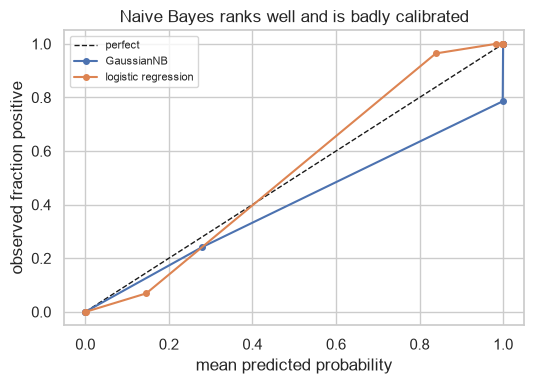

In [26]:
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect")
for name, p in (("GaussianNB", nb_proba), ("logistic regression", lr_proba)):
    frac, mean_pred = calibration_curve(yb_te, p, n_bins=8, strategy="quantile")
    ax.plot(mean_pred, frac, "o-", label=name, markersize=4)
ax.set_xlabel("mean predicted probability"); ax.set_ylabel("observed fraction positive")
ax.set_title("Naive Bayes ranks well and is badly calibrated")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

Comparable AUC, much worse Brier score, and a large fraction of predictions pinned beyond 1% or 99%.
**The ranking is usable; the numbers are not.** 8.7's `CalibratedClassifierCV` is the fix when the
probabilities matter.

In [27]:
from sklearn.calibration import CalibratedClassifierCV

calibrated = CalibratedClassifierCV(GaussianNB(), method="isotonic", cv=5).fit(Xb_tr, yb_tr)
cal_proba = calibrated.predict_proba(Xb_te)[:, 1]

print(f"raw GaussianNB   Brier {brier_score_loss(yb_te, nb_proba):.4f}   "
      f"log loss {log_loss(yb_te, nb_proba):.4f}")
print(f"+ isotonic       Brier {brier_score_loss(yb_te, cal_proba):.4f}   "
      f"log loss {log_loss(yb_te, cal_proba):.4f}")
print(f"AUC barely moves: {roc_auc_score(yb_te, nb_proba):.4f} -> "
      f"{roc_auc_score(yb_te, cal_proba):.4f}")

raw GaussianNB   Brier 0.0498   log loss 0.3084
+ isotonic       Brier 0.0416   log loss 0.1345
AUC barely moves: 0.9915 -> 0.9902


### 15.9 In Practice

#### 15.9.1 A worked case: a support-ticket triage classifier

The request: *"We get thousands of support messages a day. Route them to the right team automatically, and
tell us when the model is unsure so a human can look."*

Three properties make Naive Bayes the right first choice here, and they are worth naming before any code:
the feature space is huge (one dimension per word), the training data is whatever has been labelled so far
(15.8.2), and retraining must be cheap because the vocabulary moves (15.8.1).

In [28]:
TEAMS = {
    "billing": ["invoice", "charge", "refund", "payment", "bill"],
    "technical": ["crash", "error", "bug", "loading", "timeout"],
    "account": ["password", "profile", "delete", "cancel", "settings"],
}
FILLER = ["please", "hello", "the", "my", "your", "help", "with", "issue", "team", "thanks",
          "urgent", "today", "again", "still", "problem", "need", "cannot", "when", "this"]

TICKET_CONTAMINATION = 0.50    # half of all tickets mention another team's vocabulary
TICKET_NOISE = 0.05            # and 5% are filed under the wrong team to begin with


def make_ticket(team, gen):
    words = list(gen.choice(TEAMS[team], size=1))
    words += list(gen.choice(FILLER, size=gen.integers(6, 14)))
    if gen.random() < TICKET_CONTAMINATION:
        other = gen.choice([t for t in TEAMS if t != team])
        words += list(gen.choice(TEAMS[other], size=gen.integers(1, 3)))
    gen.shuffle(words)
    return " ".join(words)


gen = np.random.default_rng(RANDOM_STATE)
team_names = list(TEAMS)
# Deliberately imbalanced, as real ticket queues are.
true_teams = gen.choice(team_names, size=1500, p=[0.55, 0.30, 0.15])
tickets = [make_ticket(t, gen) for t in true_teams]

ticket_labels = true_teams.copy()
mis_filed = gen.random(len(ticket_labels)) < TICKET_NOISE
ticket_labels[mis_filed] = gen.choice(team_names, size=mis_filed.sum())

print(pd.Series(ticket_labels).value_counts().to_string())
print(f"\n{mis_filed.mean():.1%} of tickets were filed under the wrong team")
print("example:", tickets[0])

billing      805
technical    449
account      246



5.6% of tickets were filed under the wrong team
example: issue team today please delete loading need this when issue profile thanks still today


In [29]:
tk_tr, tk_te, ty_tr, ty_te = train_test_split(tickets, ticket_labels, test_size=0.3,
                                              stratify=ticket_labels, random_state=RANDOM_STATE)

candidates = {
    "MultinomialNB": make_pipeline(CountVectorizer(), MultinomialNB()),
    "ComplementNB": make_pipeline(CountVectorizer(), ComplementNB()),
    "TF-IDF + MultinomialNB": make_pipeline(TfidfVectorizer(), MultinomialNB()),
    "logistic regression": make_pipeline(TfidfVectorizer(), LogisticRegression(max_iter=2000)),
}

from sklearn.metrics import f1_score

for name, pipe in candidates.items():
    pipe.fit(tk_tr, ty_tr)
    pred = pipe.predict(tk_te)
    print(f"{name:<26} accuracy {pipe.score(tk_te, ty_te):.4f}   "
          f"macro F1 {f1_score(ty_te, pred, average='macro'):.4f}")

MultinomialNB              accuracy 0.5978   macro F1 0.4544
ComplementNB               accuracy 0.6444   macro F1 0.6049
TF-IDF + MultinomialNB     accuracy 0.5400   macro F1 0.2446


logistic regression        accuracy 0.6867   macro F1 0.5958


**Macro F1 is the metric that matters here**, not accuracy (8.5.4): the `account` team receives 15% of
tickets, and a model that routes everything to `billing` would still score respectably on accuracy while
being useless to two of the three teams.

**Step 2 — the "tell us when the model is unsure" requirement.** This is where 15.8.3 becomes a live
problem rather than a theoretical one: Naive Bayes' confidence is not a probability.

In [30]:
best_pipe = candidates["ComplementNB"]
confidence = best_pipe.predict_proba(tk_te).max(axis=1)
correct = best_pipe.predict(tk_te) == ty_te


def reliability(conf, corr, label):
    print(f"{label}: mean confidence {conf.mean():.4f}   actual accuracy {corr.mean():.4f}")
    for lo, hi in ((0.3, 0.5), (0.5, 0.7), (0.7, 0.9), (0.9, 1.01)):
        m = (conf >= lo) & (conf < hi)
        if m.sum() > 5:
            print(f"    confidence in [{lo}, {hi}): n={m.sum():>4}   "
                  f"claims {conf[m].mean():.3f}   delivers {corr[m].mean():.3f}")


reliability(confidence, correct, "RAW ComplementNB")

RAW ComplementNB: mean confidence 0.4678   actual accuracy 0.6444
    confidence in [0.3, 0.5): n= 322   claims 0.435   delivers 0.652
    confidence in [0.5, 0.7): n= 128   claims 0.550   delivers 0.625


The mean confidence is well *below* the actual accuracy, and the same gap appears bin by bin: tickets the
model scores around 0.44 are classified correctly about 65% of the time. **This model is under-confident**,
and a threshold of 0.7 would refuse to auto-route almost everything.

That is worth pausing on, because 15.8.3 will show the opposite on a different dataset. The reliable
statement about Naive Bayes is that its probabilities are **distorted**, not that they are always too
high: with strongly overlapping classes and short documents the posteriors get squeezed towards the
uniform $1/K$, while on cleanly separated binary problems they are pushed towards 0 and 1.

**Either way the fix is the same — calibrate, then threshold.**

In [31]:
calibrated_pipe = make_pipeline(
    CountVectorizer(),
    CalibratedClassifierCV(ComplementNB(), method="sigmoid", cv=5),
).fit(tk_tr, ty_tr)

cal_conf = calibrated_pipe.predict_proba(tk_te).max(axis=1)
cal_correct = calibrated_pipe.predict(tk_te) == ty_te

reliability(cal_conf, cal_correct, "CALIBRATED")

CALIBRATED: mean confidence 0.6229   actual accuracy 0.6444
    confidence in [0.3, 0.5): n= 111   claims 0.439   delivers 0.468
    confidence in [0.5, 0.7): n= 170   claims 0.594   delivers 0.665
    confidence in [0.7, 0.9): n= 169   claims 0.772   delivers 0.740


After calibration the claimed and delivered numbers track each other in every bin. The overall accuracy is
unchanged — calibration is monotonic per class and does not move the argmax much (8.7) — but the
confidence now means something, which is what the "tell us when the model is unsure" requirement needed.

In [32]:
# The deliverable: what fraction can be auto-routed at a required accuracy?
print(f"{'threshold':>11}{'auto-routed':>14}{'accuracy on those':>20}{'sent to a human':>18}")
for t in (0.5, 0.7, 0.8, 0.9, 0.95):
    auto = cal_conf >= t
    acc = cal_correct[auto].mean() if auto.any() else float("nan")
    print(f"{t:>11.2f}{auto.mean():>14.1%}{acc:>20.4f}{1 - auto.mean():>18.1%}")

  threshold   auto-routed   accuracy on those   sent to a human
       0.50         75.3%              0.7021             24.7%
       0.70         37.6%              0.7396             62.4%
       0.80         11.3%              0.6863             88.7%
       0.90          0.0%                 nan            100.0%
       0.95          0.0%                 nan            100.0%


**Step 3 — the report.**

> **Can tickets be routed automatically?** Partly. This is a hard problem by construction — half the
> tickets mention another team's vocabulary and 5% arrive mis-filed — and no model here exceeds about 69%
> accuracy. Auto-routing everything is not an option; auto-routing the confident subset is.
>
> **Which model?** `ComplementNB`. It reaches **macro F1 0.605** against `MultinomialNB`'s **0.454** —
> the complement formulation corrects the majority-class bias on a 55/30/15 mix (15.7). It also edges out
> TF-IDF logistic regression on macro F1 (0.605 vs 0.596), although logistic regression wins on plain
> accuracy (0.687 vs 0.644).
>
> **Why prefer the model with lower accuracy?** Because accuracy rewards getting `billing` right, and
> `billing` is 55% of the queue. Macro F1 weights the small `account` queue equally (8.5.4), and routing
> that queue correctly is the point of the exercise — a model that dumps everything into `billing` scores
> well on accuracy and helps nobody.
>
> **Can we trust the confidence scores?** **Not as they come** — though not in the direction usually
> warned about. On this problem the raw posteriors are *under*-confident: tickets scored around 0.44 are
> routed correctly about 65% of the time. Thresholding on the raw number would send almost nothing through
> automatically. Wrapping the classifier in sigmoid calibration makes the claimed and delivered accuracy
> agree bin by bin (8.7).
>
> **The operating recommendation.** Route automatically above a calibrated confidence threshold and send
> the rest to a human. At 0.5, 75% of tickets route automatically at 70% accuracy; at 0.7, 38% route at
> 74%. Pick the point from the cost of a misroute, not from the model (8.6).
>
> Note that the trend reverses at 0.8 — accuracy drops to 0.69 on the 11% of tickets above that threshold.
> That is small-sample noise, not a real effect, and it is a reminder to read a threshold table with its
> sample sizes in view (2.8.3).
>
> **What to watch.** The vocabulary drifts — new product names, new error codes. Because refitting costs
> seconds (15.8.1), retrain frequently rather than cleverly, and monitor the fraction of tickets falling
> below the threshold: a rise means the incoming language has moved away from the training data (24.9).

#### 15.9.2 When to reach for Naive Bayes

| Situation | Use it? | Instead |
|---|---|---|
| Text classification, many features | **Yes** — the classic fit (15.7) | — |
| A fast, strong baseline before anything else | **Yes** — it costs seconds | — |
| Very little labelled data | **Yes** — it needs the least (15.8.2) | — |
| Retraining must be constant and cheap | **Yes** | — |
| Streaming data | **Yes** — `partial_fit` supports true online updates | — |
| You need calibrated probabilities | Only with calibration wrapped around it (15.8.3) | Logistic regression (13.9.1) |
| Features are strongly correlated | Careful — evidence is double-counted (15.2.1) | Logistic regression, trees |
| Feature *interactions* matter | **No** — it cannot represent them at all | Trees (Ch. 17), boosting (Ch. 19) |
| Continuous features that are clearly non-normal | Not `GaussianNB` — bin them first (6.3) | Discretize, or use a tree |
| Maximum accuracy on tabular data | **No** | Gradient boosting (Ch. 19) |

The interaction row is the hard limit and deserves a demonstration: Naive Bayes fails on XOR for the same
reason logistic regression does (6.1), but for a different underlying cause — not a linear boundary, but
the independence assumption itself.

In [33]:
n_xor = 800
a = rng.normal(size=n_xor)
b = rng.normal(size=n_xor)
y_xor = ((a > 0) ^ (b > 0)).astype(int)
X_xor = np.column_stack([a, b])

from sklearn.ensemble import RandomForestClassifier

for name, model in (("GaussianNB", GaussianNB()),
                    ("logistic regression", LogisticRegression()),
                    ("random forest", RandomForestClassifier(n_estimators=100,
                                                             random_state=RANDOM_STATE))):
    score = cross_val_score(model, X_xor, y_xor, cv=cv).mean()
    print(f"{name:<21} CV accuracy {score:.4f}")

print("\nwithin each class, a and b each look like a symmetric normal centred at 0 -")
print("the per-feature marginals are IDENTICAL across classes, so NB sees no signal at all.")

GaussianNB            CV accuracy 0.4838
logistic regression   CV accuracy 0.4287


random forest         CV accuracy 0.9912

within each class, a and b each look like a symmetric normal centred at 0 -
the per-feature marginals are IDENTICAL across classes, so NB sees no signal at all.


In [34]:
nb_xor = GaussianNB().fit(X_xor, y_xor)
print("fitted per-class means (should differ if the features carried marginal signal):")
print(pd.DataFrame(nb_xor.theta_.round(4), index=["class 0", "class 1"],
                   columns=["a", "b"]).to_string())
print("\nthe means are nearly identical - exactly as the XOR construction implies.")

fitted per-class means (should differ if the features carried marginal signal):
              a       b
class 0 -0.0114  0.0261
class 1 -0.0688  0.0665

the means are nearly identical - exactly as the XOR construction implies.


#### 15.9.3 What goes wrong in production

| Failure | What it looks like | Where |
|---|---|---|
| **Confidence taken at face value** | Auto-routing sends mistakes through at "99% confidence" | 15.8.3, 15.9.1 |
| **Unseen vocabulary** | New words are silently ignored; accuracy drifts down | 15.5, 6.6 |
| **`alpha` never tuned** | The default 1.0 over-smooths a small vocabulary or under-smooths a large one | 15.5 |
| **Features standardized upstream** | `MultinomialNB` raises on negative input | 15.4 |
| **Correlated features added** | Confidence rises, accuracy does not; calibration degrades further | 15.2.1 |
| **Class balance shifts** | The prior is baked in from training and no longer matches reality | Below |

The last row is specific to Naive Bayes and easy to fix, which makes it worth knowing. The prior $P(c)$ is
estimated from the training data. If the real class mix changes — a marketing campaign shifts the ticket
mix, a fraud wave changes the base rate — the fitted prior is wrong, and **it can be replaced without
refitting the likelihoods.**

In [35]:
# Training mix vs a shifted production mix.
trained = make_pipeline(CountVectorizer(), MultinomialNB()).fit(tk_tr, ty_tr)
nb_model = trained[-1]

print("prior learned from training data:")
print(f"  {dict(zip(nb_model.classes_, np.exp(nb_model.class_log_prior_).round(3)))}")

# Suppose technical tickets have doubled in production.
production_prior = np.array([0.40, 0.15, 0.45])          # billing, account, technical (alphabetical)
adjusted = make_pipeline(CountVectorizer(), MultinomialNB(fit_prior=False,
                                                          class_prior=production_prior))
adjusted.fit(tk_tr, ty_tr)

print(f"\nprior supplied explicitly:")
print(f"  {dict(zip(adjusted[-1].classes_, production_prior))}")
print("\nthe word likelihoods are unchanged; only the prior moved.")
print("likelihoods identical:",
      np.allclose(trained[-1].feature_log_prob_, adjusted[-1].feature_log_prob_))

prior learned from training data:
  {np.str_('account'): np.float64(0.164), np.str_('billing'): np.float64(0.537), np.str_('technical'): np.float64(0.299)}

prior supplied explicitly:
  {np.str_('account'): np.float64(0.4), np.str_('billing'): np.float64(0.15), np.str_('technical'): np.float64(0.45)}

the word likelihoods are unchanged; only the prior moved.
likelihoods identical: True


`class_prior` lets the deployed model track a changing base rate at zero cost. No other model in this
material separates "what the classes look like" from "how common they are" so cleanly — in logistic
regression the same correction requires refitting or an intercept adjustment.

In [36]:
# --- 15. Naive Bayes — scratch cell ---
# Experiments for this chapter. Promote anything worth keeping into the
# relevant section as a proper example cell.

